<a href="https://colab.research.google.com/github/nagahemaramishetty/log-analysis-anomaly-detection/blob/main/Log_Analysis_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─── STEP 1: Download & Load NASA HTTP Server Log Dataset ───

# Step 1.1 — Download the raw compressed log file from NASA's public FTP archive
!wget -q "ftp://ita.ee.lbl.gov/traces/NASA_access_log_Jul95.gz" -O NASA_access_log_Jul95.gz
print("Downloading completed")

# Step 1.2 — Decompress the .gz file to extract the raw .log file
!gunzip -f NASA_access_log_Jul95.gz
print("Decompression complete")

# Step 1.3 — Load raw log lines into memory
log_file_path = "NASA_access_log_Jul95"

with open(log_file_path, "r", encoding="utf-8", errors="ignore") as f:
    raw_logs = f.readlines()

# Step 1.4 — Inspect volume and structure
total_lines = len(raw_logs)
print(f"Total log lines loaded: {total_lines:,}")
print(f"\n--- Sample Raw Log Lines (first 5) ---")
for line in raw_logs[:5]:
    print(line.strip())

Decompression complete
Total log lines loaded: 1,891,715

--- Sample Raw Log Lines (first 5) ---
199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] "GET /history/apollo/ HTTP/1.0" 200 6245
unicomp6.unicomp.net - - [01/Jul/1995:00:00:06 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985
199.120.110.21 - - [01/Jul/1995:00:00:09 -0400] "GET /shuttle/missions/sts-73/mission-sts-73.html HTTP/1.0" 200 4085
burger.letters.com - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/countdown/liftoff.html HTTP/1.0" 304 0
199.120.110.21 - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/missions/sts-73/sts-73-patch-small.gif HTTP/1.0" 200 4179


In [2]:
# ─── STEP 2: Regex Parsing — Unstructured Logs → Structured DataFrame ───

import re
import pandas as pd

# Step 2.1 — Define Regex pattern with named capture groups matching CLF format
log_pattern = re.compile(
    r'(?P<host>\S+)\s+'          # Client IP or hostname
    r'\S+\s+\S+\s+'              # Ident and auth (usually - -)
    r'\[(?P<timestamp>[^\]]+)\]\s+'  # Timestamp inside brackets
    r'"(?P<method>\S+)\s+'       # HTTP method
    r'(?P<endpoint>\S+)\s+'      # Requested endpoint/URL
    r'(?P<protocol>[^"]+)"\s+'   # HTTP protocol version
    r'(?P<status>\d{3})\s+'      # HTTP status code
    r'(?P<bytes>\S+)'            # Response size in bytes
)

# Step 2.2 — Parse all raw log lines using the Regex pattern
parsed_records = []
parse_failures = 0

for line in raw_logs:
    match = log_pattern.search(line)
    if match:
        parsed_records.append(match.groupdict())
    else:
        parse_failures += 1

# Step 2.3 — Convert parsed records into a structured Pandas DataFrame
df = pd.DataFrame(parsed_records)

# Step 2.4 — Type casting — convert status and bytes to numeric
df['status'] = pd.to_numeric(df['status'], errors='coerce')
df['bytes'] = pd.to_numeric(df['bytes'], errors='coerce').fillna(0).astype(int)

# Step 2.5 — Parse timestamp string into datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%b/%Y:%H:%M:%S %z', errors='coerce')

# Step 2.6 — Report parse accuracy
total = len(raw_logs)
parsed = len(parsed_records)
parse_accuracy = (parsed / total) * 100

print(f"Total lines processed : {total:,}")
print(f"Successfully parsed   : {parsed:,}")
print(f"Parse failures        : {parse_failures:,}")
print(f"Parse accuracy        : {parse_accuracy:.2f}%")
print(f"\n--- DataFrame Shape: {df.shape} ---")
print(f"\n--- DataFrame Schema ---")
print(df.dtypes)
print(f"\n--- Sample Structured Records (first 5) ---")
print(df.head())

Total lines processed : 1,891,715
Successfully parsed   : 1,888,739
Parse failures        : 2,976
Parse accuracy        : 99.84%

--- DataFrame Shape: (1888739, 7) ---

--- DataFrame Schema ---
host                            object
timestamp    datetime64[ns, UTC-04:00]
method                          object
endpoint                        object
protocol                        object
status                           int64
bytes                            int64
dtype: object

--- Sample Structured Records (first 5) ---
                   host                 timestamp method  \
0          199.72.81.55 1995-07-01 00:00:01-04:00    GET   
1  unicomp6.unicomp.net 1995-07-01 00:00:06-04:00    GET   
2        199.120.110.21 1995-07-01 00:00:09-04:00    GET   
3    burger.letters.com 1995-07-01 00:00:11-04:00    GET   
4        199.120.110.21 1995-07-01 00:00:11-04:00    GET   

                                          endpoint  protocol  status  bytes  
0                                 /

--- HTTP Status Code Distribution ---
status
200    1698659
302      46547
304     132627
403         54
404      10776
500         62
501         14
Name: count, dtype: int64


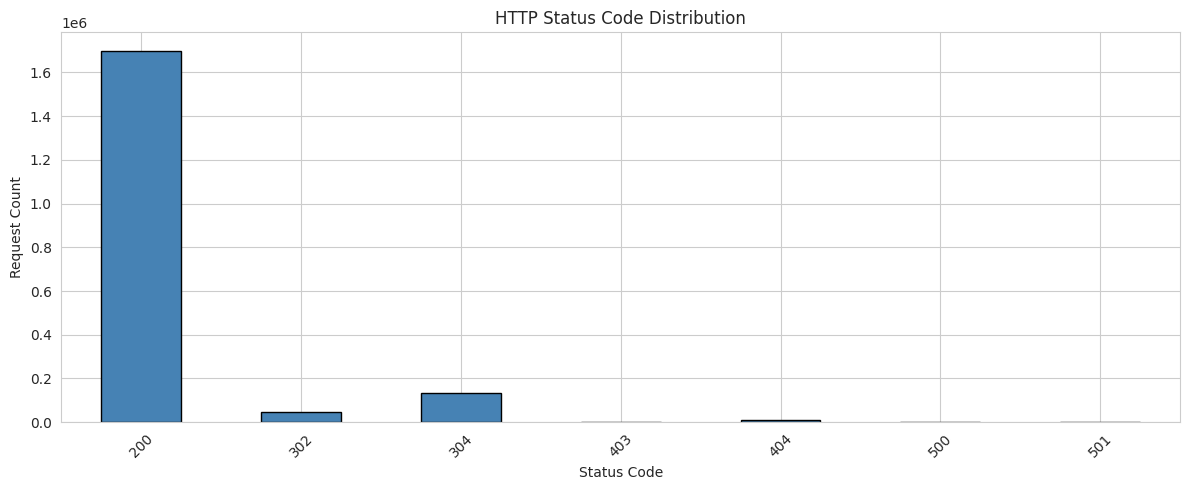


--- Top 10 Most Requested Endpoints ---
endpoint
/images/NASA-logosmall.gif      111144
/images/KSC-logosmall.gif        89530
/images/MOSAIC-logosmall.gif     60300
/images/USA-logosmall.gif        59845
/images/WORLD-logosmall.gif      59325
/images/ksclogo-medium.gif       58616
/images/launch-logo.gif          40841
/shuttle/countdown/              40251
/ksc.html                        40073
/images/ksclogosmall.gif         33555
Name: count, dtype: int64


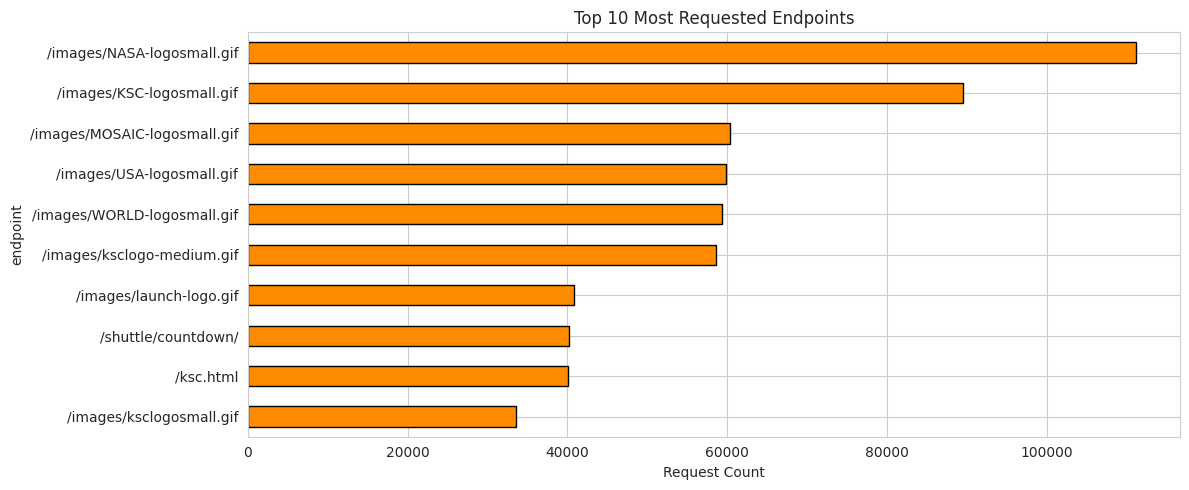


--- Hourly Request Volume ---


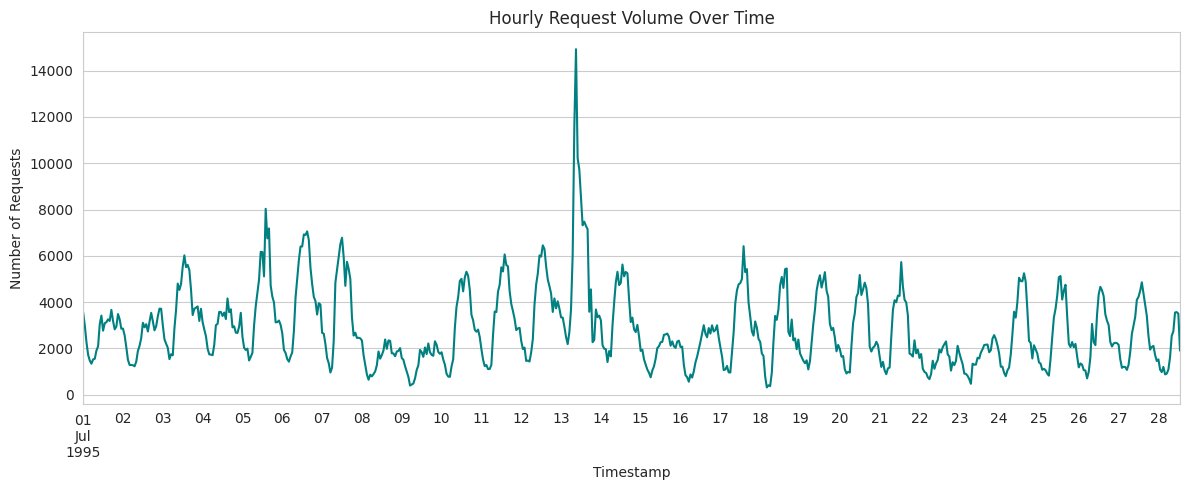


--- Daily Traffic Trend ---
timestamp
1995-07-01 00:00:00-04:00     64557
1995-07-02 00:00:00-04:00     60163
1995-07-03 00:00:00-04:00     89508
1995-07-04 00:00:00-04:00     70371
1995-07-05 00:00:00-04:00     94448
1995-07-06 00:00:00-04:00    100838
1995-07-07 00:00:00-04:00     87140
1995-07-08 00:00:00-04:00     38793
1995-07-09 00:00:00-04:00     35229
1995-07-10 00:00:00-04:00     72731
1995-07-11 00:00:00-04:00     80328
1995-07-12 00:00:00-04:00     92400
1995-07-13 00:00:00-04:00    134134
1995-07-14 00:00:00-04:00     83944
1995-07-15 00:00:00-04:00     45451
1995-07-16 00:00:00-04:00     47794
1995-07-17 00:00:00-04:00     74877
1995-07-18 00:00:00-04:00     64100
1995-07-19 00:00:00-04:00     72599
1995-07-20 00:00:00-04:00     66489
1995-07-21 00:00:00-04:00     64499
1995-07-22 00:00:00-04:00     35194
1995-07-23 00:00:00-04:00     39117
1995-07-24 00:00:00-04:00     64151
1995-07-25 00:00:00-04:00     62495
1995-07-26 00:00:00-04:00     58682
1995-07-27 00:00:00-04:00

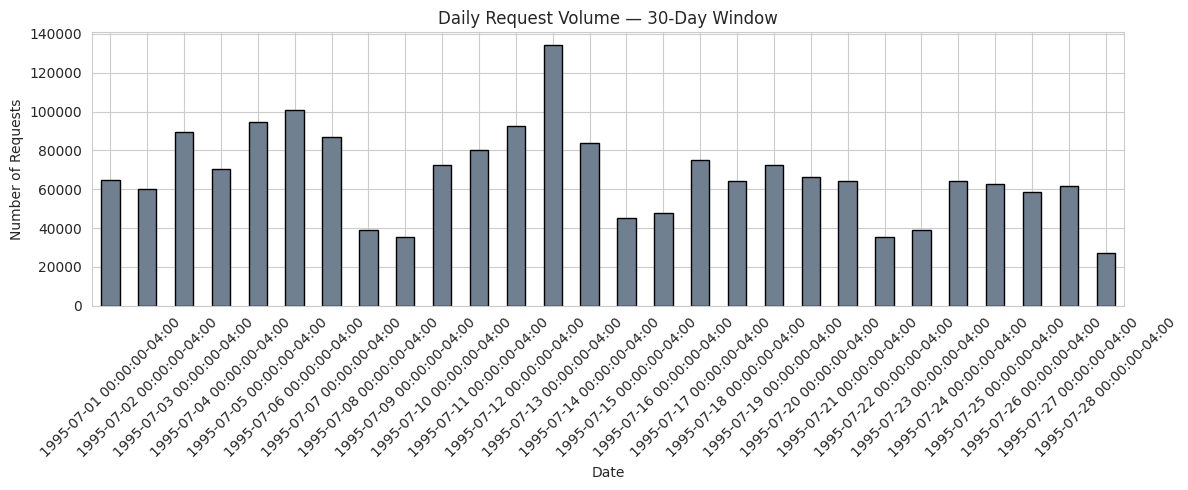


--- Error Rate Analysis ---
Total Requests   : 1,888,739
Error Requests   : 10,906
Overall Error Rate: 0.58%

--- Bytes Transferred — Descriptive Statistics ---
count    1.888739e+06
mean     2.044346e+04
std      7.693142e+04
min      0.000000e+00
25%      7.860000e+02
50%      3.635000e+03
75%      1.185300e+04
max      6.823936e+06
Name: bytes, dtype: float64


In [4]:
# STEP 3: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Step 3.1 - HTTP Status Code Distribution
print("--- HTTP Status Code Distribution ---")
status_counts = df['status'].value_counts().sort_index()
print(status_counts)

plt.figure()
status_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('HTTP Status Code Distribution')
plt.xlabel('Status Code')
plt.ylabel('Request Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 3.2 - Top 10 Most Requested Endpoints
print("\n--- Top 10 Most Requested Endpoints ---")
top_endpoints = df['endpoint'].value_counts().head(10)
print(top_endpoints)

plt.figure()
top_endpoints.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Top 10 Most Requested Endpoints')
plt.xlabel('Request Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Step 3.3 - Hourly Request Volume (temporal pattern baseline)
print("\n--- Hourly Request Volume ---")
df_indexed = df.set_index('timestamp').sort_index()
hourly_requests = df_indexed['status'].resample('h').count()

plt.figure()
hourly_requests.plot(color='teal')
plt.title('Hourly Request Volume Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Number of Requests')
plt.tight_layout()
plt.show()

# Step 3.4 - Daily Traffic Trend
print("\n--- Daily Traffic Trend ---")
daily_requests = df_indexed['status'].resample('D').count()
print(daily_requests)

plt.figure()
daily_requests.plot(kind='bar', color='slategray', edgecolor='black')
plt.title('Daily Request Volume — 30-Day Window')
plt.xlabel('Date')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 3.5 - Error Rate Analysis (4xx + 5xx status codes)
print("\n--- Error Rate Analysis ---")
total_requests = len(df)
error_requests = df[df['status'] >= 400].shape[0]
error_rate = (error_requests / total_requests) * 100
print(f"Total Requests   : {total_requests:,}")
print(f"Error Requests   : {error_requests:,}")
print(f"Overall Error Rate: {error_rate:.2f}%")

# Step 3.6 - Bytes Transferred Distribution (outlier signal)
print("\n--- Bytes Transferred — Descriptive Statistics ---")
print(df['bytes'].describe())

Total hourly windows: 662
                  timestamp  request_count  hour_of_day  day_of_week  \
0 1995-07-01 00:00:00-04:00           3558            0            5   
1 1995-07-01 01:00:00-04:00           2989            1            5   
2 1995-07-01 02:00:00-04:00           2268            2            5   
3 1995-07-01 03:00:00-04:00           1723            3            5   
4 1995-07-01 04:00:00-04:00           1475            4            5   

   day_of_month  
0             1  
1             1  
2             1  
3             1  
4             1  
Isolation Forest model trained successfully

Total hourly windows analyzed : 662
Anomalies detected            : 14
Anomaly rate                  : 2.11%

--- Top 10 Anomalous Windows by Request Count ---
                    timestamp  request_count  anomaly_score
297 1995-07-13 09:00:00-04:00          14925      -0.074140
296 1995-07-13 08:00:00-04:00          11559      -0.042103
298 1995-07-13 10:00:00-04:00          10214    

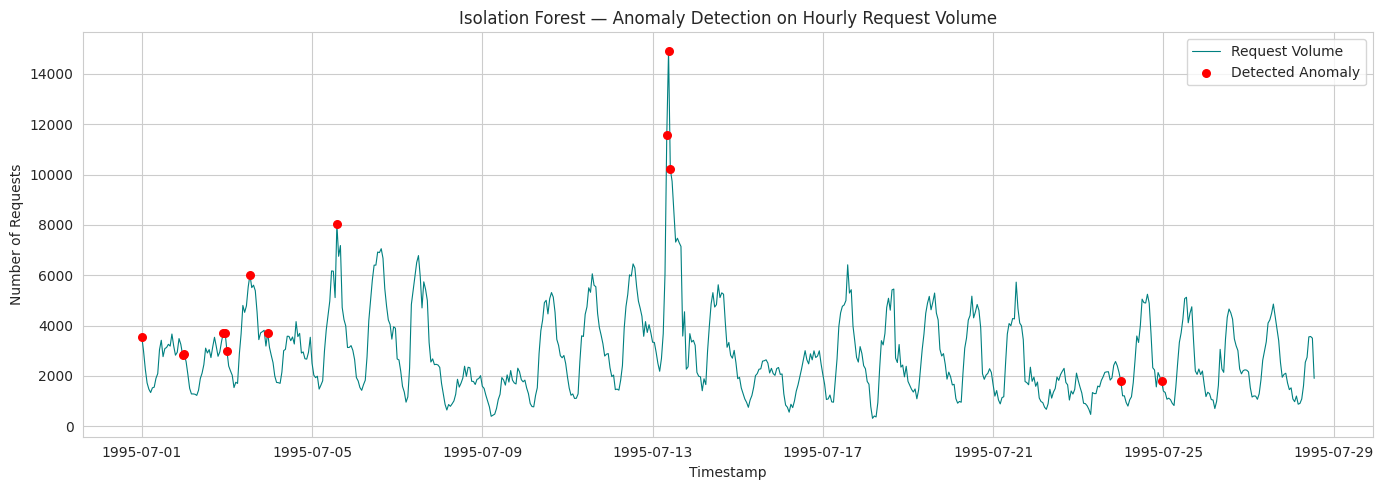

In [5]:
# STEP 4: Anomaly Detection — Isolation Forest

from sklearn.ensemble import IsolationForest
import numpy as np

# Step 4.1 - Rebuild hourly request volume with lowercase resample (FutureWarning fix)
hourly_requests = df_indexed['status'].resample('h').count().reset_index()
hourly_requests.columns = ['timestamp', 'request_count']

# Step 4.2 - Feature engineering — extract temporal context features
hourly_requests['hour_of_day'] = hourly_requests['timestamp'].dt.hour
hourly_requests['day_of_week'] = hourly_requests['timestamp'].dt.dayofweek
hourly_requests['day_of_month'] = hourly_requests['timestamp'].dt.day

print(f"Total hourly windows: {len(hourly_requests):,}")
print(hourly_requests.head())

# Step 4.3 - Define feature matrix for Isolation Forest
features = ['request_count', 'hour_of_day', 'day_of_week', 'day_of_month']
X = hourly_requests[features].values

# Step 4.4 - Train Isolation Forest model
iso_forest = IsolationForest(
    n_estimators=100,       # Number of isolation trees in the ensemble
    contamination=0.02,     # Expected proportion of anomalies in the dataset
    random_state=42,        # Reproducibility seed
    n_jobs=-1               # Parallelize across all available CPU cores
)

iso_forest.fit(X)
print("Isolation Forest model trained successfully")

# Step 4.5 - Generate predictions and anomaly scores
hourly_requests['anomaly_label'] = iso_forest.predict(X)
hourly_requests['anomaly_score'] = iso_forest.decision_function(X)

# -1 = anomaly, 1 = normal — convert to readable labels
hourly_requests['is_anomaly'] = hourly_requests['anomaly_label'].apply(
    lambda x: 'Anomaly' if x == -1 else 'Normal'
)

# Step 4.6 - Summarize detected anomalies
total_windows = len(hourly_requests)
anomaly_count = (hourly_requests['anomaly_label'] == -1).sum()
anomaly_rate = (anomaly_count / total_windows) * 100

print(f"\nTotal hourly windows analyzed : {total_windows:,}")
print(f"Anomalies detected            : {anomaly_count:,}")
print(f"Anomaly rate                  : {anomaly_rate:.2f}%")
print(f"\n--- Top 10 Anomalous Windows by Request Count ---")
print(hourly_requests[hourly_requests['is_anomaly'] == 'Anomaly']
      .sort_values('request_count', ascending=False)
      .head(10)[['timestamp', 'request_count', 'anomaly_score']])

# Step 4.7 - Visualize anomalies overlaid on time series
plt.figure(figsize=(14, 5))
plt.plot(hourly_requests['timestamp'],
         hourly_requests['request_count'],
         color='teal', linewidth=0.8, label='Request Volume')

anomalies = hourly_requests[hourly_requests['is_anomaly'] == 'Anomaly']
plt.scatter(anomalies['timestamp'],
            anomalies['request_count'],
            color='red', s=30, zorder=5, label='Detected Anomaly')

plt.title('Isolation Forest — Anomaly Detection on Hourly Request Volume')
plt.xlabel('Timestamp')
plt.ylabel('Number of Requests')
plt.legend()
plt.tight_layout()
plt.show()

Daily time series length: 28 days
timestamp
1995-07-01 00:00:00-04:00     64557
1995-07-02 00:00:00-04:00     60163
1995-07-03 00:00:00-04:00     89508
1995-07-04 00:00:00-04:00     70371
1995-07-05 00:00:00-04:00     94448
1995-07-06 00:00:00-04:00    100838
1995-07-07 00:00:00-04:00     87140
1995-07-08 00:00:00-04:00     38793
1995-07-09 00:00:00-04:00     35229
1995-07-10 00:00:00-04:00     72731
1995-07-11 00:00:00-04:00     80328
1995-07-12 00:00:00-04:00     92400
1995-07-13 00:00:00-04:00    134134
1995-07-14 00:00:00-04:00     83944
1995-07-15 00:00:00-04:00     45451
1995-07-16 00:00:00-04:00     47794
1995-07-17 00:00:00-04:00     74877
1995-07-18 00:00:00-04:00     64100
1995-07-19 00:00:00-04:00     72599
1995-07-20 00:00:00-04:00     66489
1995-07-21 00:00:00-04:00     64499
1995-07-22 00:00:00-04:00     35194
1995-07-23 00:00:00-04:00     39117
1995-07-24 00:00:00-04:00     64151
1995-07-25 00:00:00-04:00     62495
1995-07-26 00:00:00-04:00     58682
1995-07-27 00:00:00-

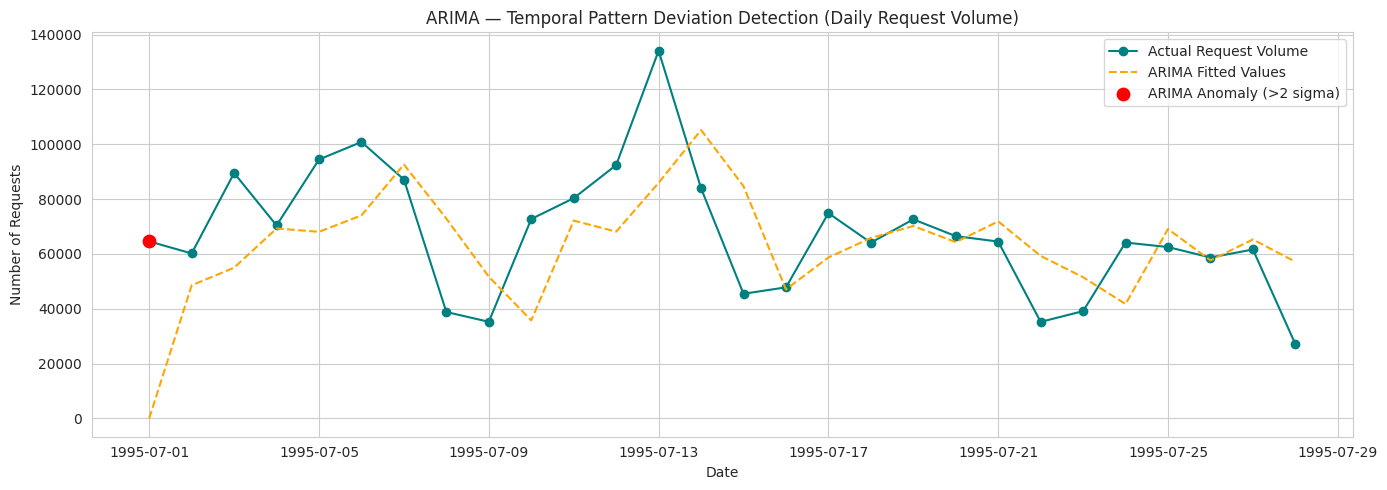

In [6]:
# STEP 5: ARIMA — Temporal Pattern Deviation Detection

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Step 5.1 - Prepare daily request volume time series
daily_requests = df_indexed['status'].resample('D').count()
print(f"Daily time series length: {len(daily_requests)} days")
print(daily_requests)

# Step 5.2 - Augmented Dickey-Fuller test for stationarity
adf_result = adfuller(daily_requests.dropna())
print(f"\nADF Statistic  : {adf_result[0]:.4f}")
print(f"p-value        : {adf_result[1]:.4f}")
print(f"Stationarity   : {'Stationary (p < 0.05)' if adf_result[1] < 0.05 else 'Non-Stationary — differencing required'}")

# Step 5.3 - Fit ARIMA model
# p=2 (AR order), d=1 (differencing), q=2 (MA order)
arima_model = ARIMA(daily_requests, order=(2, 1, 2))
arima_result = arima_model.fit()

print(f"\nARIMA Model Summary:")
print(arima_result.summary())

# Step 5.4 - Generate in-sample fitted values and residuals
fitted_values = arima_result.fittedvalues
residuals = arima_result.resid

# Step 5.5 - Define anomaly threshold — 2 standard deviations from mean residual
residual_std = residuals.std()
residual_mean = residuals.mean()
upper_threshold = residual_mean + (2 * residual_std)
lower_threshold = residual_mean - (2 * residual_std)

print(f"\nResidual Mean      : {residual_mean:.2f}")
print(f"Residual Std Dev   : {residual_std:.2f}")
print(f"Upper Threshold (+2 sigma): {upper_threshold:.2f}")
print(f"Lower Threshold (-2 sigma): {lower_threshold:.2f}")

# Step 5.6 - Flag days where residuals exceed 2-sigma threshold
daily_df = pd.DataFrame({
    'actual': daily_requests,
    'fitted': fitted_values,
    'residual': residuals
})

daily_df['is_anomaly'] = daily_df['residual'].apply(
    lambda x: 'Anomaly' if (x > upper_threshold or x < lower_threshold) else 'Normal'
)

anomaly_days = daily_df[daily_df['is_anomaly'] == 'Anomaly']
print(f"\nARIMA Flagged Anomalous Days: {len(anomaly_days)}")
print(anomaly_days[['actual', 'fitted', 'residual']])

# Step 5.7 - Visualize ARIMA fitted vs actual with anomaly flags
plt.figure(figsize=(14, 5))
plt.plot(daily_df.index, daily_df['actual'],
         label='Actual Request Volume', color='teal', marker='o', linewidth=1.5)
plt.plot(daily_df.index, daily_df['fitted'],
         label='ARIMA Fitted Values', color='orange', linestyle='--', linewidth=1.5)

arima_anomalies = daily_df[daily_df['is_anomaly'] == 'Anomaly']
plt.scatter(arima_anomalies.index, arima_anomalies['actual'],
            color='red', s=80, zorder=5, label='ARIMA Anomaly (>2 sigma)')

plt.title('ARIMA — Temporal Pattern Deviation Detection (Daily Request Volume)')
plt.xlabel('Date')
plt.ylabel('Number of Requests')
plt.legend()
plt.tight_layout()
plt.show()